In [42]:
import pandas as pd
from datetime import datetime
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import adfuller
import math
from sklearn.preprocessing import StandardScaler

## Data

In [43]:
# import data
df= pd.read_csv("import_2022.csv")

In [44]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2605 entries, 0 to 2604
Data columns (total 61 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   qa3_01         2605 non-null   int64
 1   qa3_02         2605 non-null   int64
 2   qa3_03         2605 non-null   int64
 3   qa3_04         2605 non-null   int64
 4   qa3_05         2605 non-null   int64
 5   qa3_06         2605 non-null   int64
 6   qa3_07         2605 non-null   int64
 7   qa3_08         2605 non-null   int64
 8   qa3_09         2605 non-null   int64
 9   qa4_01         2605 non-null   int64
 10  qa4_02         2605 non-null   int64
 11  qa4_03         2605 non-null   int64
 12  qa4_04         2605 non-null   int64
 13  qa4_05         2605 non-null   int64
 14  qa4_06         2605 non-null   int64
 15  qa4_07         2605 non-null   int64
 16  qa4_08         2605 non-null   int64
 17  qa4_09         2605 non-null   int64
 18  qa13_01        2605 non-null   int64
 19  qa13_02        26

None

## Risk Aversion

### Gain - 50%の確率で10万円が当たる「スピードくじ」の値段

Transformed price = 1 − λ/50,000 <br>
Note that the greater a respondent’s value of transformed price, the more risk averse the respondent is. In our setting, the values of transformed price only take values between zero and one, where the value of zero corresponds to the case of perfectly risk-neutral preference.

In [46]:
# Function to calculate calculate_price based on conditions
def calculate_price(row):
    conditions = {
        (2, 2, 2, 2, 2, 2, 2, 2): 0.9998,
        (1, 2, 2, 2, 2, 2, 2, 2): 0.9799,
        (1, 1, 2, 2, 2, 2, 2, 2): 0.94,
        (1, 1, 1, 2, 2, 2, 2, 2): 0.88,
        (1, 1, 1, 1, 2, 2, 2, 2): 0.77,
        (1, 1, 1, 1, 1, 2, 2, 2): 0.6,
        (1, 1, 1, 1, 1, 1, 2, 2): 0.4,
        (1, 1, 1, 1, 1, 1, 1, 2): 0.15,
        (1, 1, 1, 1, 1, 1, 1, 1): 0
        
    }
    # Ensure the order matches exactly as in your conditions dictionary
    key = (row['qa15_01'], row['qa15_02'], row['qa15_03'], row['qa15_04'],
           row['qa15_05'], row['qa15_06'], row['qa15_07'], row['qa15_08'])
    return conditions.get(key, 'unknown')  # return 'unknown' if no match is found

# Apply function to calculate rho
df['Risk_Gain'] = df.apply(calculate_price, axis=1)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2605 entries, 0 to 2604
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   qa3_01         2605 non-null   int64 
 1   qa3_02         2605 non-null   int64 
 2   qa3_03         2605 non-null   int64 
 3   qa3_04         2605 non-null   int64 
 4   qa3_05         2605 non-null   int64 
 5   qa3_06         2605 non-null   int64 
 6   qa3_07         2605 non-null   int64 
 7   qa3_08         2605 non-null   int64 
 8   qa3_09         2605 non-null   int64 
 9   qa4_01         2605 non-null   int64 
 10  qa4_02         2605 non-null   int64 
 11  qa4_03         2605 non-null   int64 
 12  qa4_04         2605 non-null   int64 
 13  qa4_05         2605 non-null   int64 
 14  qa4_06         2605 non-null   int64 
 15  qa4_07         2605 non-null   int64 
 16  qa4_08         2605 non-null   int64 
 17  qa4_09         2605 non-null   int64 
 18  qa13_01        2605 non-null   int64 
 

## Male 

In [48]:
df['Male'] = df['Male12'].apply(lambda x: 1 if x == 1 else 0)

## Marital Status

In [49]:
df['Spouse'] = df['qb2'].apply(lambda x: 1 if x == 1 or x == 2 else 0)

## Age

In [50]:
# Function to calculate age
def calculate_age(year, month):
    today = datetime.today()
    birth_date = datetime(year, month, 1)
    age = today.year - birth_date.year - ((today.month, today.day) < (birth_date.month, birth_date.day))
    return age

# Create a new column for age
df['Age'] = df.apply(lambda row: calculate_age(row['qb3y'], row['qb3m']), axis=1)

## Housing

In [51]:
df['Residence'] = df['qb33'].apply(lambda x: 1 if x == 1 or x == 2 else 0)

## Income, Property, Financial Assets, 

In [52]:
# Income, property, and financial-asset encodings
# Main encoding: midpoint-like monetary values used in the manuscript.
# Robustness encodings: ordinal rank and log-midpoint.
# These additional columns are kept only for the encoding robustness check below.

INCOME_MIDPOINT_MAP = {
    1: 100, 2: 150, 3: 300, 4: 500, 5: 700, 6: 900,
    7: 1100, 8: 1300, 9: 1500, 10: 1700, 11: 1900, 12: 2000,
}

PROPERTY_MIDPOINT_MAP = {
    1: 0, 2: 500, 3: 750, 4: 1250, 5: 1750,
    6: 2500, 7: 3500, 8: 4500, 9: 7500, 10: 10000,
}

FIN_ASSET_MIDPOINT_MAP = {
    1: 250, 2: 375, 3: 625, 4: 875, 5: 1250,
    6: 1750, 7: 2500, 8: 4000, 9: 7500, 10: 10000,
}

# Main midpoint encoding used in the manuscript.
df['Income'] = df['Income_pre'].map(INCOME_MIDPOINT_MAP).astype(float)
df['Property'] = df['Property_pre'].map(PROPERTY_MIDPOINT_MAP).astype(float)
df['Fin_Asset'] = df['Fin_Asset_pre'].map(FIN_ASSET_MIDPOINT_MAP).astype(float)

# Alternative 1: ordinal-rank encoding.
# This uses only the order of the survey categories and does not assume that the
# distance between two adjacent categories is proportional to the monetary midpoint.
df['Income_rank'] = df['Income_pre'].where(df['Income_pre'].isin(INCOME_MIDPOINT_MAP.keys()), np.nan).astype(float)
df['Property_rank'] = df['Property_pre'].where(df['Property_pre'].isin(PROPERTY_MIDPOINT_MAP.keys()), np.nan).astype(float)
df['Fin_Asset_rank'] = df['Fin_Asset_pre'].where(df['Fin_Asset_pre'].isin(FIN_ASSET_MIDPOINT_MAP.keys()), np.nan).astype(float)

# Alternative 2: log-midpoint encoding.
# This preserves the midpoint ordering while compressing large top categories.
df['Income_logmid'] = np.log1p(df['Income'])
df['Property_logmid'] = np.log1p(df['Property'])
df['Fin_Asset_logmid'] = np.log1p(df['Fin_Asset'])


In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2605 entries, 0 to 2604
Data columns (total 75 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   qa3_01            2605 non-null   int64  
 1   qa3_02            2605 non-null   int64  
 2   qa3_03            2605 non-null   int64  
 3   qa3_04            2605 non-null   int64  
 4   qa3_05            2605 non-null   int64  
 5   qa3_06            2605 non-null   int64  
 6   qa3_07            2605 non-null   int64  
 7   qa3_08            2605 non-null   int64  
 8   qa3_09            2605 non-null   int64  
 9   qa4_01            2605 non-null   int64  
 10  qa4_02            2605 non-null   int64  
 11  qa4_03            2605 non-null   int64  
 12  qa4_04            2605 non-null   int64  
 13  qa4_05            2605 non-null   int64  
 14  qa4_06            2605 non-null   int64  
 15  qa4_07            2605 non-null   int64  
 16  qa4_08            2605 non-null   int64  
 17  qa4_09

## Asset Type

In [54]:
# List of columns to check
columns_to_check = [f'qb36{str(i).zfill(2)}' for i in range(1, 15)]

# Filter out rows with any value of 9 in the specified columns
df_cleaned = df[~df[columns_to_check].isin([9]).any(axis=1)].copy()


In [55]:
# １ 銀行預金（信用金庫、信用組合、農協などを含む）
# ２ 郵便貯金 ３ 生命保険 ４ 株式 
# ５ 投資信託 ６ 外貨預金 ７ 先物・オプション
# ８ 日本の国債 ９ 外国債 10 個人年金（生命保険会社や郵便年金）
# 11 企業年金 12 現金貯金（いわゆるタンス預金）
# 13 その他（ ）

# List of columns to sum for Asset_Type, excluding qb3608
columns_to_sum = [f'qb36{str(i).zfill(2)}' for i in range(4, 9)]

# Create the new column 'Asset_Type' by summing the specified columns
df_cleaned['Asset_Type'] = df_cleaned[columns_to_sum].sum(axis=1)

In [56]:
df_cleaned['Stock'] = df['qb3604'].apply(lambda x: 1 if x == 1 else 0)
df_cleaned['MF'] = df['qb3605'].apply(lambda x: 1 if x == 1 else 0)

In [57]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 2493 entries, 0 to 2604
Data columns (total 78 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   qa3_01            2493 non-null   int64  
 1   qa3_02            2493 non-null   int64  
 2   qa3_03            2493 non-null   int64  
 3   qa3_04            2493 non-null   int64  
 4   qa3_05            2493 non-null   int64  
 5   qa3_06            2493 non-null   int64  
 6   qa3_07            2493 non-null   int64  
 7   qa3_08            2493 non-null   int64  
 8   qa3_09            2493 non-null   int64  
 9   qa4_01            2493 non-null   int64  
 10  qa4_02            2493 non-null   int64  
 11  qa4_03            2493 non-null   int64  
 12  qa4_04            2493 non-null   int64  
 13  qa4_05            2493 non-null   int64  
 14  qa4_06            2493 non-null   int64  
 15  qa4_07            2493 non-null   int64  
 16  qa4_08            2493 non-null   int64  
 17  qa4_09     

In [58]:
df_filtered = df_cleaned[(df_cleaned['Risk_Gain'] != 'unknown')]
df_filtered.info()

<class 'pandas.DataFrame'>
Index: 2381 entries, 0 to 2604
Data columns (total 78 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   qa3_01            2381 non-null   int64  
 1   qa3_02            2381 non-null   int64  
 2   qa3_03            2381 non-null   int64  
 3   qa3_04            2381 non-null   int64  
 4   qa3_05            2381 non-null   int64  
 5   qa3_06            2381 non-null   int64  
 6   qa3_07            2381 non-null   int64  
 7   qa3_08            2381 non-null   int64  
 8   qa3_09            2381 non-null   int64  
 9   qa4_01            2381 non-null   int64  
 10  qa4_02            2381 non-null   int64  
 11  qa4_03            2381 non-null   int64  
 12  qa4_04            2381 non-null   int64  
 13  qa4_05            2381 non-null   int64  
 14  qa4_06            2381 non-null   int64  
 15  qa4_07            2381 non-null   int64  
 16  qa4_08            2381 non-null   int64  
 17  qa4_09     

In [59]:
# Drop columns starting with 'qa'
columns_to_drop = [col for col in df_filtered.columns if col.startswith('q')]
df_filtered = df_filtered.drop(columns=columns_to_drop)
df_filtered.info()

<class 'pandas.DataFrame'>
Index: 2381 entries, 0 to 2604
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rain              2381 non-null   int64  
 1   Male12            2381 non-null   int64  
 2   Income_pre        2381 non-null   int64  
 3   Property_pre      2381 non-null   int64  
 4   Fin_Asset_pre     2381 non-null   int64  
 5   Risky_Asset       2381 non-null   int64  
 6   Risk_Gain         2381 non-null   object 
 7   Male              2381 non-null   int64  
 8   Spouse            2381 non-null   int64  
 9   Age               2381 non-null   int64  
 10  Residence         2381 non-null   int64  
 11  Income            2247 non-null   float64
 12  Property          2262 non-null   float64
 13  Fin_Asset         2184 non-null   float64
 14  Income_rank       2247 non-null   float64
 15  Property_rank     2262 non-null   float64
 16  Fin_Asset_rank    2184 non-null   float64
 17  Income_logm

In [60]:
df_filtered = df_filtered.drop(columns=['Male12','Income_pre','Property_pre','Fin_Asset_pre'])

In [61]:
# Further filter the DataFrame based on the specified conditions
conditions = (
    (df_filtered['Rain'] != 999) 
#     &
#     (df_filtered['Income'] != 99) &
#     (df_filtered['Property'] != 99) &
#     (df_filtered['Fin_Asset'] != 99) 
#    &(~df_filtered['Risky_Asset'].isin([888, 999]))
)

df_filtered = df_filtered[conditions]

#df_filtered = df_filtered[~((df_filtered['Risky_Asset'] > 0) & (df_filtered['Asset_Type'] == 0))]

df_filtered.info()

<class 'pandas.DataFrame'>
Index: 2328 entries, 0 to 2604
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rain              2328 non-null   int64  
 1   Risky_Asset       2328 non-null   int64  
 2   Risk_Gain         2328 non-null   object 
 3   Male              2328 non-null   int64  
 4   Spouse            2328 non-null   int64  
 5   Age               2328 non-null   int64  
 6   Residence         2328 non-null   int64  
 7   Income            2197 non-null   float64
 8   Property          2212 non-null   float64
 9   Fin_Asset         2138 non-null   float64
 10  Income_rank       2197 non-null   float64
 11  Property_rank     2212 non-null   float64
 12  Fin_Asset_rank    2138 non-null   float64
 13  Income_logmid     2197 non-null   float64
 14  Property_logmid   2212 non-null   float64
 15  Fin_Asset_logmid  2138 non-null   float64
 16  Asset_Type        2328 non-null   int64  
 17  Stock      

In [62]:
df_filtered['Risk_Gain'] = pd.to_numeric(df_filtered['Risk_Gain'])

In [63]:
df_filtered.dropna(inplace = True)

In [64]:
df_filtered.info()
# df_filtered.to_csv(r"D:\_滋賀大学\03_Demographics\data_sf.csv", encoding="shift_jis")

<class 'pandas.DataFrame'>
Index: 2056 entries, 0 to 2604
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rain              2056 non-null   int64  
 1   Risky_Asset       2056 non-null   int64  
 2   Risk_Gain         2056 non-null   float64
 3   Male              2056 non-null   int64  
 4   Spouse            2056 non-null   int64  
 5   Age               2056 non-null   int64  
 6   Residence         2056 non-null   int64  
 7   Income            2056 non-null   float64
 8   Property          2056 non-null   float64
 9   Fin_Asset         2056 non-null   float64
 10  Income_rank       2056 non-null   float64
 11  Property_rank     2056 non-null   float64
 12  Fin_Asset_rank    2056 non-null   float64
 13  Income_logmid     2056 non-null   float64
 14  Property_logmid   2056 non-null   float64
 15  Fin_Asset_logmid  2056 non-null   float64
 16  Asset_Type        2056 non-null   int64  
 17  Stock      

In [65]:
# Keep an unstandardized copy of the final analysis sample.
# This is used for the encoding robustness check so that each encoding
# is standardized in the same way immediately before FCI is run.
df_analysis_raw = df_filtered.copy()
print(df_analysis_raw.shape)


(2056, 19)


標準化

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [67]:
# Define continuous and categorical columns
continuous_cols = ['Rain','Income','Property','Fin_Asset','Risky_Asset','Risk_Gain','Age','Asset_Type']
categorical_cols = ['Male','Spouse','Residence','Stock','MF']

# Standardize continuous columns
scaler = StandardScaler(with_mean=False)
df_filtered[continuous_cols] = scaler.fit_transform(df_filtered[continuous_cols])

# Print the standardized DataFrame
print(df_filtered)

          Rain  Risky_Asset  Risk_Gain  Male  Spouse       Age  Residence  \
0     2.521911     0.000000   4.751099     1       1  6.378880          1   
1     2.017529     0.130330   1.900820     1       1  6.293828          1   
2     2.017529     0.000000   2.851230     1       1  5.018052          1   
3     3.026293     0.000000   4.181803     0       1  6.038673          1   
7     2.521911     3.254984   4.751099     0       0  7.484552          1   
...        ...          ...        ...   ...     ...       ...        ...   
2600  4.035058     0.016291   4.181803     0       1  5.783518          1   
2601  4.035058     0.000000   4.181803     0       0  3.231966          0   
2602  1.513147     2.893319   4.181803     1       1  6.038673          1   
2603  1.513147     0.097747   2.851230     1       0  3.146914          1   
2604  2.521911     0.065165   3.659078     1       1  4.422690          1   

        Income  Property  Fin_Asset  Income_rank  Property_rank  \
0     0.

In [68]:
df_filtered=df_filtered.drop(columns=['Asset_Type', 'Risky_Asset'])

In [69]:
display(df_filtered.info())

<class 'pandas.DataFrame'>
Index: 2056 entries, 0 to 2604
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rain              2056 non-null   float64
 1   Risk_Gain         2056 non-null   float64
 2   Male              2056 non-null   int64  
 3   Spouse            2056 non-null   int64  
 4   Age               2056 non-null   float64
 5   Residence         2056 non-null   int64  
 6   Income            2056 non-null   float64
 7   Property          2056 non-null   float64
 8   Fin_Asset         2056 non-null   float64
 9   Income_rank       2056 non-null   float64
 10  Property_rank     2056 non-null   float64
 11  Fin_Asset_rank    2056 non-null   float64
 12  Income_logmid     2056 non-null   float64
 13  Property_logmid   2056 non-null   float64
 14  Fin_Asset_logmid  2056 non-null   float64
 15  Stock             2056 non-null   int64  
 16  MF                2056 non-null   int64  
dtypes: float64(

None

# FCI

https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/FCI.html#algorithm-introduction

In [70]:
#「PC/FCIにおいて混合データを扱うための機能の実装」に対応した causal-learn をインストールするためには、次のコマンドを実行します。
# !pip install git+https://github.com/cdt15/causal-learn.git

In [71]:
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import kci
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
# visualization
from causallearn.utils.GraphUtils import GraphUtils
import pydot
import io
import matplotlib.image as mpimg

In [72]:
# Randomly select 1200 samples
# df_sampled = df_filtered.sample(n=1200, random_state=42)

In [73]:
# Explicit variable order used by FCI.
# This avoids accidental inclusion of the auxiliary encoding columns used for robustness checks.
ANALYSIS_COLS = [
    'Rain',
    'Risk_Gain',
    'Male',
    'Spouse',
    'Age',
    'Residence',
    'Income',
    'Property',
    'Fin_Asset',
    'Stock',
    'MF',
]

CONTINUOUS_ANALYSIS_COLS = ['Rain', 'Risk_Gain', 'Age', 'Income', 'Property', 'Fin_Asset']
IS_DISCRETE = [False, False, True, True, False, True, False, False, False, True, True]

# Main manuscript analysis uses the midpoint encoding columns.
data_pre = df_filtered[ANALYSIS_COLS].to_numpy()
print(df_filtered[ANALYSIS_COLS].head())
print("FCI input shape:", data_pre.shape)


       Rain  Risk_Gain  Male  Spouse       Age  Residence    Income  Property  \
0  2.521911   4.751099     1       1  6.378880          1  0.745070  0.232755   
1  2.017529   1.900820     1       1  6.293828          1  0.745070  0.232755   
2  2.017529   2.851230     1       1  5.018052          1  1.241784  0.232755   
3  3.026293   4.181803     0       1  6.038673          1  1.738497  3.491325   
7  2.521911   4.751099     0       0  7.484552          1  0.248357  0.232755   

   Fin_Asset  Stock  MF  
0   0.167711      0   0  
1   0.559036      1   0  
2   0.279518      0   0  
3   3.354217      0   0  
7   0.279518      0   0  
FCI input shape: (2056, 11)


In [74]:
#G, edges = fci(data_pre, 'kci', 0.05)

In [75]:
# cg_without_background_knowledge = fci(
#     data_pre, 
#     is_discrete=[False, False, True, True, False, True, False, False, False, True, True],
#     independence_test_method="kci"
# )

In [76]:
from causallearn.graph.GraphNode import GraphNode

# causal-learn uses generic node names X1, X2, ..., in the data order.
nodes = [GraphNode(f"X{i}") for i in range(1, len(ANALYSIS_COLS) + 1)]

for node, label in zip(nodes, ANALYSIS_COLS):
    print(node.get_name(), "=", label)

# Background knowledge:
# Male and Age are treated as exogenous; therefore, all other variables are forbidden
# from causing Male or Age. Indexing follows ANALYSIS_COLS above.
forbidden_edges = [
    # no variable other than Male itself causes Male (index 2)
    (0,2), (1,2), (3,2), (4,2), (5,2), (6,2), (7,2), (8,2), (9,2), (10,2),
    # no variable other than Age itself causes Age (index 4)
    (0,4), (1,4), (2,4), (3,4), (5,4), (6,4), (7,4), (8,4), (9,4), (10,4),
]

def make_background_knowledge():
    bk = BackgroundKnowledge()
    for node_1_idx, node_2_idx in forbidden_edges:
        bk.add_forbidden_by_node(nodes[node_1_idx], nodes[node_2_idx])
    return bk


X1 = Rain
X2 = Risk_Gain
X3 = Male
X4 = Spouse
X5 = Age
X6 = Residence
X7 = Income
X8 = Property
X9 = Fin_Asset
X10 = Stock
X11 = MF


In [37]:
bk = make_background_knowledge()

G, edges = fci(
    data_pre,
    is_discrete=IS_DISCRETE,
    independence_test_method="kci",
    background_knowledge=bk,
)


Depth=0, working on node 10: 100%|██████████| 11/11 [00:12<00:00,  1.10s/it]


Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
X7 --> X2
X7 --> X4
X8 --> X7
X9 --> X8
X9 --> X10


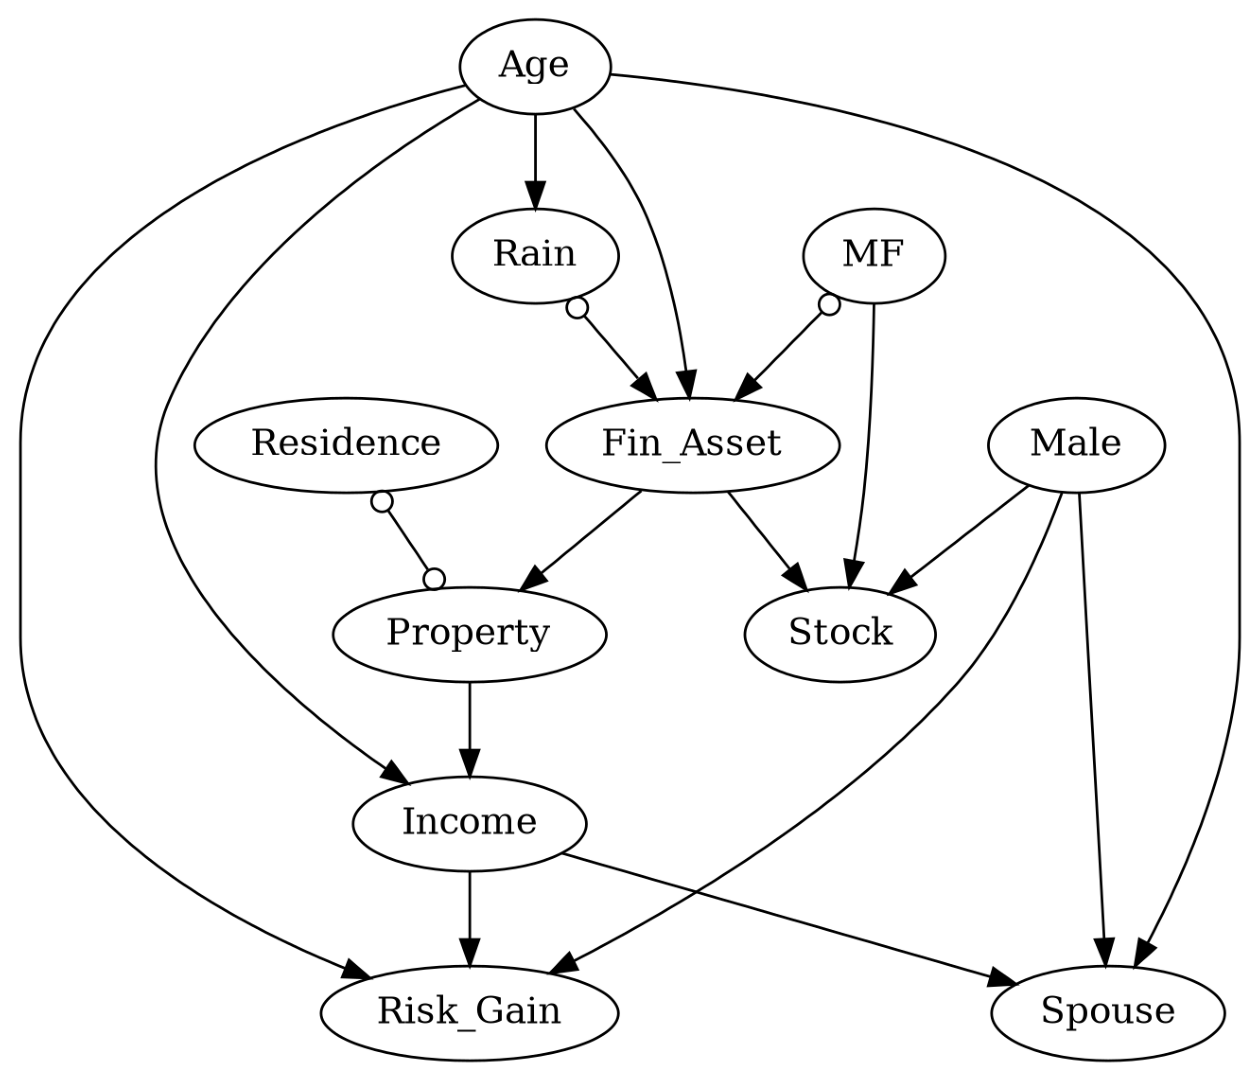

In [38]:
pyd = GraphUtils.to_pydot(G, labels=ANALYSIS_COLS)

tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')
plt.figure(figsize=(16,16))
plt.axis('off')
plt.imshow(img)
plt.show()


# Minimal encoding robustness check

This section addresses the reviewer comment on the encoding of ordinal socioeconomic variables.
The main manuscript encodes `Income`, `Property`, and `Fin_Asset` using monetary midpoint-like values.
As a minimal robustness check, we rerun FCI once after replacing these three variables with ordinal-rank encodings.
An optional log-midpoint encoding is also included. No bootstrap resampling is used here.


In [77]:
from pathlib import Path
import json

ENCODING_ROBUSTNESS_DIR = Path("./encoding_robustness")
ENCODING_ROBUSTNESS_DIR.mkdir(parents=True, exist_ok=True)

# Each entry maps the analysis variable name to the column in df_analysis_raw.
# "midpoint" is the main manuscript encoding.
# "rank" is the minimal robustness check requested by the reviewer.
# "log_midpoint" is optional but useful as an additional monotone alternative.
ENCODING_VARIANTS = {
    "midpoint_main": {
        "Income": "Income",
        "Property": "Property",
        "Fin_Asset": "Fin_Asset",
    },
    "rank_minimal_check": {
        "Income": "Income_rank",
        "Property": "Property_rank",
        "Fin_Asset": "Fin_Asset_rank",
    },
    "log_midpoint_optional": {
        "Income": "Income_logmid",
        "Property": "Property_logmid",
        "Fin_Asset": "Fin_Asset_logmid",
    },
}

# Use the same FCI variable order and discrete/continuous designation as the main analysis.
print("Analysis columns:", ANALYSIS_COLS)
print("Discrete flags:", IS_DISCRETE)
print("Encoding variants:", list(ENCODING_VARIANTS.keys()))


Analysis columns: ['Rain', 'Risk_Gain', 'Male', 'Spouse', 'Age', 'Residence', 'Income', 'Property', 'Fin_Asset', 'Stock', 'MF']
Discrete flags: [False, False, True, True, False, True, False, False, False, True, True]
Encoding variants: ['midpoint_main', 'rank_minimal_check', 'log_midpoint_optional']


In [78]:
def build_analysis_df_for_encoding(df_raw: pd.DataFrame, variant_spec: dict) -> pd.DataFrame:
    """Create the FCI input dataframe for a given encoding of Income/Property/Fin_Asset.

    The function starts from the final unstandardized analysis sample, replaces the three
    ordinal socioeconomic variables according to `variant_spec`, selects the 11 analysis
    variables in the fixed order, and standardizes only the continuous variables.
    """
    out = df_raw.copy()

    for target_col, source_col in variant_spec.items():
        out[target_col] = out[source_col]

    out = out[ANALYSIS_COLS].copy()

    # Standardize continuous variables in the same manner as the main analysis.
    scaler = StandardScaler(with_mean=False)
    out[CONTINUOUS_ANALYSIS_COLS] = scaler.fit_transform(out[CONTINUOUS_ANALYSIS_COLS])

    return out


def run_fci_for_encoding(encoding_name: str, variant_spec: dict):
    """Run FCI once for a given encoding. No bootstrap is used."""
    analysis_df = build_analysis_df_for_encoding(df_analysis_raw, variant_spec)
    data_np = analysis_df.to_numpy()
    bk = make_background_knowledge()

    print(f"Running FCI for encoding = {encoding_name}, shape = {data_np.shape}")
    graph, edge_list = fci(
        data_np,
        is_discrete=IS_DISCRETE,
        independence_test_method="kci",
        background_knowledge=bk,
    )

    return {
        "encoding": encoding_name,
        "analysis_df": analysis_df,
        "graph": graph,
        "edges": edge_list,
    }


node_to_label = {f"X{i+1}": label for i, label in enumerate(ANALYSIS_COLS)}
label_to_order = {label: i for i, label in enumerate(ANALYSIS_COLS)}


def canonical_edge_tuple(edge):
    """Return an edge tuple with a stable node order for comparison across encodings."""
    n1 = node_to_label.get(edge.node1.get_name(), edge.node1.get_name())
    n2 = node_to_label.get(edge.node2.get_name(), edge.node2.get_name())
    e1 = edge.endpoint1.name
    e2 = edge.endpoint2.name

    if label_to_order[n1] <= label_to_order[n2]:
        return (n1, n2, e1, e2)
    return (n2, n1, e2, e1)


def adjacency_tuple(edge_tuple):
    return edge_tuple[0], edge_tuple[1]


In [ ]:
encoding_results = {}

for encoding_name, variant_spec in ENCODING_VARIANTS.items():
    encoding_results[encoding_name] = run_fci_for_encoding(encoding_name, variant_spec)

# Save edge lists for each encoding.
edge_rows = []
for encoding_name, result in encoding_results.items():
    for edge in result["edges"]:
        a, b, ea, eb = canonical_edge_tuple(edge)
        edge_rows.append({
            "encoding": encoding_name,
            "node1": a,
            "node2": b,
            "endpoint1": ea,
            "endpoint2": eb,
            "edge_mark": f"{ea}-{eb}",
        })

encoding_edges_df = pd.DataFrame(edge_rows).sort_values(["encoding", "node1", "node2"])
encoding_edges_path = ENCODING_ROBUSTNESS_DIR / "encoding_robustness_edges.csv"
encoding_edges_df.to_csv(encoding_edges_path, index=False)

print("Saved:", encoding_edges_path)
display(encoding_edges_df)


Running FCI for encoding = midpoint_main, shape = (2056, 11)


Depth=0, working on node 10: 100%|██████████| 11/11 [00:12<00:00,  1.09s/it]


Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
X7 --> X2
X7 --> X4
X8 --> X7
X9 --> X8
X9 --> X10
Running FCI for encoding = rank_minimal_check, shape = (2056, 11)


Depth=0, working on node 10: 100%|██████████| 11/11 [00:11<00:00,  1.03s/it]


Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
X9 --> X8
X9 --> X10
Running FCI for encoding = log_midpoint_optional, shape = (2056, 11)


Depth=0, working on node 10: 100%|██████████| 11/11 [00:12<00:00,  1.12s/it]


Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.


## Save and display PAGs for each encoding variant



In [ ]:
from IPython.display import display, Markdown

PAG_OUTPUT_DIR = ENCODING_ROBUSTNESS_DIR / "pag_outputs"
PAG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_and_display_pag_for_encoding(result: dict, output_dir: Path = PAG_OUTPUT_DIR):
    """Save and display the PAG for one encoding variant.

    Outputs:
      - PAG_<encoding>.png: quick inspection / Word
      - PAG_<encoding>.pdf: LaTeX-ready vector figure
      - PAG_<encoding>.dot: Graphviz source file for later editing

    The node labels follow ANALYSIS_COLS so the figures use the manuscript variable names
    rather than causal-learn's internal X1, X2, ... labels.
    """
    encoding_name = result["encoding"]
    graph = result["graph"]

    pyd = GraphUtils.to_pydot(graph, labels=ANALYSIS_COLS)
    pyd.set_label(f"PAG: {encoding_name}")
    pyd.set_labelloc("t")
    pyd.set_fontsize("20")

    safe_name = encoding_name.replace("/", "_").replace(" ", "_")
    dot_path = output_dir / f"PAG_{safe_name}.dot"
    png_path = output_dir / f"PAG_{safe_name}.png"
    pdf_path = output_dir / f"PAG_{safe_name}.pdf"

    # DOT is useful if PNG/PDF rendering is unavailable on a particular machine.
    pyd.write_raw(str(dot_path))

    saved_paths = {"dot": dot_path}

    try:
        pyd.write_png(str(png_path))
        saved_paths["png"] = png_path
    except Exception as exc:
        print(f"Could not write PNG for {encoding_name}: {exc}")

    try:
        pyd.write_pdf(str(pdf_path))
        saved_paths["pdf"] = pdf_path
    except Exception as exc:
        print(f"Could not write PDF for {encoding_name}: {exc}")

    display(Markdown(f"### PAG for `{encoding_name}`"))
    print(f"Saved PAG files for {encoding_name}:")
    for key, path in saved_paths.items():
        print(f"  {key}: {path}")

    # Display the PNG in the notebook if it was successfully created.
    if png_path.exists():
        img = mpimg.imread(str(png_path))
        plt.figure(figsize=(16, 16))
        plt.axis("off")
        plt.imshow(img)
        plt.show()

    return saved_paths


pag_output_rows = []
for encoding_name, result in encoding_results.items():
    paths = save_and_display_pag_for_encoding(result)
    pag_output_rows.append({
        "encoding": encoding_name,
        "dot_path": str(paths.get("dot", "")),
        "png_path": str(paths.get("png", "")),
        "pdf_path": str(paths.get("pdf", "")),
    })

pag_output_df = pd.DataFrame(pag_output_rows)
pag_output_path = ENCODING_ROBUSTNESS_DIR / "encoding_robustness_pag_outputs.csv"
pag_output_df.to_csv(pag_output_path, index=False)

print("Saved PAG output index:", pag_output_path)
display(pag_output_df)


In [ ]:
# Compare each alternative encoding with the main midpoint encoding.
base_name = "midpoint_main"
base_edges = {canonical_edge_tuple(e) for e in encoding_results[base_name]["edges"]}
base_adj = {adjacency_tuple(e) for e in base_edges}

summary_rows = []
detail_rows = []

for encoding_name, result in encoding_results.items():
    edges_set = {canonical_edge_tuple(e) for e in result["edges"]}
    adj_set = {adjacency_tuple(e) for e in edges_set}

    if encoding_name == base_name:
        continue

    shared_adj = base_adj & adj_set
    union_adj = base_adj | adj_set
    added_adj = adj_set - base_adj
    removed_adj = base_adj - adj_set

    shared_exact = base_edges & edges_set
    union_exact = base_edges | edges_set

    summary_rows.append({
        "comparison": f"{encoding_name} vs {base_name}",
        "n_edges_base_exact": len(base_edges),
        "n_edges_alt_exact": len(edges_set),
        "n_shared_exact_edges": len(shared_exact),
        "exact_edge_jaccard": len(shared_exact) / len(union_exact) if union_exact else np.nan,
        "n_adjacencies_base": len(base_adj),
        "n_adjacencies_alt": len(adj_set),
        "n_shared_adjacencies": len(shared_adj),
        "adjacency_jaccard": len(shared_adj) / len(union_adj) if union_adj else np.nan,
        "n_added_adjacencies": len(added_adj),
        "n_removed_adjacencies": len(removed_adj),
    })

    all_pairs = sorted(union_adj, key=lambda x: (label_to_order[x[0]], label_to_order[x[1]]))
    for a, b in all_pairs:
        base_marks = sorted([f"{ea}-{eb}" for x1, x2, ea, eb in base_edges if (x1, x2) == (a, b)])
        alt_marks = sorted([f"{ea}-{eb}" for x1, x2, ea, eb in edges_set if (x1, x2) == (a, b)])
        detail_rows.append({
            "comparison": f"{encoding_name} vs {base_name}",
            "node1": a,
            "node2": b,
            "in_base_midpoint": (a, b) in base_adj,
            "in_alternative": (a, b) in adj_set,
            "base_edge_marks": ";".join(base_marks),
            "alternative_edge_marks": ";".join(alt_marks),
            "status": (
                "shared" if ((a, b) in base_adj and (a, b) in adj_set)
                else "added_by_alternative" if (a, b) in adj_set
                else "removed_by_alternative"
            ),
        })

encoding_summary_df = pd.DataFrame(summary_rows)
encoding_detail_df = pd.DataFrame(detail_rows)

summary_path = ENCODING_ROBUSTNESS_DIR / "encoding_robustness_summary.csv"
detail_path = ENCODING_ROBUSTNESS_DIR / "encoding_robustness_edge_comparison.csv"
encoding_summary_df.to_csv(summary_path, index=False)
encoding_detail_df.to_csv(detail_path, index=False)

print("Saved:", summary_path)
print("Saved:", detail_path)
display(encoding_summary_df.round(3))
display(encoding_detail_df)
